In [2]:
import torch
#.nn will automatically create a weight matrix for you which will be optimized during training
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
#Planetoid is a specific dataset loader provided by pytorch library
#instead of bulding our own adjacency matrix it gives us a downloadable dataobject 
from torch_geometric.nn import GCNConv
#Loading the dataset
dataset=Planetoid(root='/tmp/Cora',name='Cora')
data=dataset[0]
print(f"Dataset info:")
print(f"No of nodes:{data.num_nodes}")
print(f"No of features per node:{dataset.num_features}")
print(f"No of target communities/classes:{dataset.num_classes}")



Dataset info:
No of nodes:2708
No of features per node:1433
No of target communities/classes:7


what are these 1433 features per node ?? like instead of processing raw sentences or paragraphs converts the text of each academic paper into a binary vector of length 1433 i mean its a kind of dictonary if that word is present in the paper the node of the paper containing and at that work index it is kept as 1 or else 0

In [3]:
#defining the 2 layer architechture for GCN
class GCN(torch.nn.Module):
    def __init__(self,num_features,num_classes):
        super(GCN,self).__init__()
        self.conv1=GCNConv(num_features,16)
        #layer1 takes raw input features and converts them into an hidden 16d vector
        self.conv2=GCNConv(16,num_classes)
        #layer2 will convert those 16d vector of each node into 7d in this case which represents the probability of how much it belong to each category
    def forward(self,data):
        x,edge_index=data.x,data.edge_index
        #x is the feature matrix and edge_index is adjacency matrix stored in efficient way [2,no of edges]
        x=self.conv1(x,edge_index)
        x=F.relu(x)
        x=F.dropout(x,p=0.5,training=self.training)
        x=self.conv2(x,edge_index)
        return F.log_softmax(x,dim=1)
#the below steps are about setting up the execution environment 
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#cuda is a NVDIAs platform which allows pytorch to use GPU and we will use it if avaliable 
model=GCN(num_features=dataset.num_features,num_classes=dataset.num_classes).to(device)
#moving the weights to cuda VRAM if avaliable 
data=data.to(device)
#moving data also to VRAM if cuda is active 

optimizer=torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion=torch.nn.NLLLoss()



In [4]:
#training the model
#representing one single epoch
def train():
    model.train()
    optimizer.zero_grad() # removing the previous errors
    #farword pass
    out=model(data)
    loss=criterion(out[data.train_mask],data.y[data.train_mask])
    #backpropagating the loss to intial layers 
    loss.backward()
    #as we know the loss now we are trying to update the weights based on loss
    optimizer.step()
    return loss.item()

@torch.no_grad()
# we are doing this to turn off the memory engine while running the function 
# because while training in memort there will so my calculation for updating weight and calculating the loss but while testing we dont need all those 
def test():
    model.eval()
    out = model(data)
    pred = out.argmax(dim=1)  # Get the class with highest probability
    
    # Check predictions against true labels
    correct = pred == data.y
    
    # Calculate accuracy for training, validation, and testing splits
    train_acc = int(correct[data.train_mask].sum()) / int(data.train_mask.sum())
    val_acc = int(correct[data.val_mask].sum()) / int(data.val_mask.sum())
    test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())
    
    return train_acc, val_acc, test_acc
#the train test split happens during the evaluation ohase is done by planetoid where it will create three binary hidden arrays and based on true or false
#of each node that node will be fallen into that category 

#running the model
for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = test()
    
    if epoch % 20 == 0:
        print(f"Epoch: {epoch:d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")



Epoch: 20, Loss: 0.2681, Train Acc: 0.9929, Val Acc: 0.7760, Test Acc: 0.8040
Epoch: 40, Loss: 0.0438, Train Acc: 1.0000, Val Acc: 0.7700, Test Acc: 0.7850
Epoch: 60, Loss: 0.0449, Train Acc: 1.0000, Val Acc: 0.7700, Test Acc: 0.7860
Epoch: 80, Loss: 0.0627, Train Acc: 1.0000, Val Acc: 0.7740, Test Acc: 0.7840
Epoch: 100, Loss: 0.0332, Train Acc: 1.0000, Val Acc: 0.7660, Test Acc: 0.7990
Epoch: 120, Loss: 0.0323, Train Acc: 1.0000, Val Acc: 0.7660, Test Acc: 0.7930
Epoch: 140, Loss: 0.0323, Train Acc: 1.0000, Val Acc: 0.7700, Test Acc: 0.7940
Epoch: 160, Loss: 0.0212, Train Acc: 1.0000, Val Acc: 0.7780, Test Acc: 0.8030
Epoch: 180, Loss: 0.0260, Train Acc: 1.0000, Val Acc: 0.7700, Test Acc: 0.8050
Epoch: 200, Loss: 0.0276, Train Acc: 1.0000, Val Acc: 0.7780, Test Acc: 0.8090


In [5]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
#extracting the embeddings of each node of GCN
#we are extracting 16d vector output of first layer instead of final 7d because it is normalized one for getting category of papers
@torch.no_grad()
def get_embeddings(model, data):
    model.eval()
    # Manually pass through the first layer exactly like the forward function
    x = model.conv1(data.x, data.edge_index)
    x = torch.relu(x)
    # Move to CPU and convert to a standard NumPy array for Scikit-Learn
    return x.cpu().numpy()

# Extract the 16-dimensional vectors for all 2,708 nodes
embeddings = get_embeddings(model, data)
print(f"Extracted embeddings matrix shape: {embeddings.shape}")


Extracted embeddings matrix shape: (2708, 16)


In [6]:
#now we are going to use k means clustering on this cora dataset for community detection
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(embeddings)
#here we are choosing no of clusters is 7 because we already know num_classes in cora dataset
#evaluating the community detection
true_labels = data.y.cpu().numpy()

# Compute evaluation scores
ari_score = adjusted_rand_score(true_labels, cluster_assignments)
nmi_score = normalized_mutual_info_score(true_labels, cluster_assignments)

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")


Adjusted Rand Index (ARI): 0.5299
Normalized Mutual Information (NMI): 0.5599


The NMI mainly depends on entropy and uncertainity like it answers the question for us like if i know which cluster does the node belong to how much i am certain about its academin topic
suppose you are thorwing all 2300 nodes into 7 different bags and in bag 1 there should be onlt nodes belongs to category 1 and if by picking a node from bag1 how much certain are u it belongs to category 1 .
Normalized Mutual Information (NMI) measures the similarity between the ground-truth communities and the communities predicted by a clustering algorithm.

$$
\text{NMI}(\Omega, C) = \frac{I(\Omega; C)}{\sqrt{H(\Omega) \cdot H(C)}}
$$

Where:

- **$\Omega$ (Omega)**: Ground-truth partitioning (the actual community labels).
- **$C$**: Clustering partitioning generated by the algorithm (e.g., K-Means).
- **$I(\Omega; C)$ (Mutual Information)**: Measures how much information is shared between the true communities and the predicted communities. It quantifies how much uncertainty about the true labels is reduced when the predicted labels are known.
- **$H(\Omega)$ and $H(C)$ (Entropy)**: Measure the uncertainty or diversity within the true communities and predicted communities respectively.

The normalization term

$$
\sqrt{H(\Omega) \cdot H(C)}
$$

ensures that the score remains between **0 and 1**, making it easier to compare clustering results across different datasets.

### Interpretation

- **NMI = 1**: Perfect agreement between predicted and true communities.
- **NMI = 0**: No relationship between predicted and true communities.
- **0 < NMI < 1**: Partial agreement, with higher values indicating better clustering quality.

This should render correctly in both Jupyter Notebook and GitHub Markdown previews.

Running t-SNE (this might take a few seconds)...


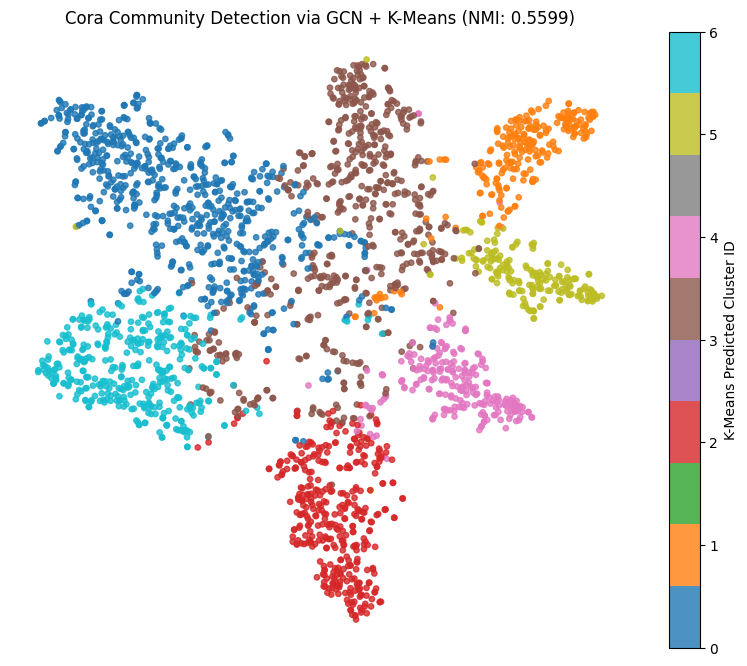

In [7]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import normalized_mutual_info_score
#reducing the dimensions to plot in graph
#SNE is a sort of dimensionality reduction technique
print("Running t-SNE (this might take a few seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)  # Shape becomes: (2708, 2)
#30 perplexity is no of nodes it is closely looking to covert into 2d
#plotting 
plt.figure(figsize=(10, 8))

# Scatter plot: X = column 0, Y = column 1
# c=cluster_assignments colors each dot by its K-Means predicted community
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_assignments,
    cmap="tab10",
    s=15,
    alpha=0.8,
)

plt.colorbar(scatter, label="K-Means Predicted Cluster ID")
plt.title(f"Cora Community Detection via GCN + K-Means (NMI: {nmi_score:.4f})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.axis("off")  # Hides gridlines for a cleaner look
plt.show()

In [8]:
import pandas as pd
#Testing whether changing the hidden dimension will change the 

#hidden dimensions that i wanted to test
hidden_dimensions_to_test = [4, 16, 32, 64, 128]

# Dictionary to store results for final reporting
experiment_results = {
    "Hidden Dimension": [], 
    "Final Test Accuracy": [], 
    "K-Means NMI": []
}

for hidden_dim in hidden_dimensions_to_test:
    print(f" Training with Hidden Dimension = {hidden_dim}")
    
    # re intializing the layers accoring to hidden dimension 
    model.conv1 = GCNConv(dataset.num_features, hidden_dim).to(device)
    model.conv2 = GCNConv(hidden_dim, dataset.num_classes).to(device)
    
    # Reset optimizer for the new weights
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    for epoch in range(1, 201):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
    # evaluating the results 
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)
        correct = pred == data.y
        test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())
        
    # extracting the embeddings afer layer 1 
    with torch.no_grad():
        hidden_embeddings = model.conv1(data.x, data.edge_index)
        hidden_embeddings = torch.relu(hidden_embeddings).cpu().numpy()
        
    # running k means algorithm on them for community detection 
    kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
    cluster_assignments = kmeans.fit_predict(hidden_embeddings)
    
    # results
    true_labels = data.y.cpu().numpy()
    nmi_score = normalized_mutual_info_score(true_labels, cluster_assignments)
    
    # appending the statistics 
    experiment_results["Hidden Dimension"].append(hidden_dim)
    experiment_results["Final Test Accuracy"].append(f"{test_acc * 100:.2f}%")
    experiment_results["K-Means NMI"].append(f"{nmi_score:.4f}")


print("             Final results            ")
df_results = pd.DataFrame(experiment_results)
print(df_results.to_string(index=False))


 Training with Hidden Dimension = 4
 Training with Hidden Dimension = 16
 Training with Hidden Dimension = 32
 Training with Hidden Dimension = 64
 Training with Hidden Dimension = 128
             Final results            
 Hidden Dimension Final Test Accuracy K-Means NMI
                4              75.20%      0.4485
               16              79.30%      0.5568
               32              81.70%      0.5613
               64              81.50%      0.5692
              128              81.70%      0.5494


In [9]:
#now trying to experiment by changing the depth of the layers in GCN architehcture
#the hidden vector size is 32 fixed 
import sys
import os
#moving to community detection folder notebook folder like moving top
root_path=os.path.abspath(os.path.join('..'))
#now searching for src folder
src_path=os.path.join(root_path,'src')
#adding src path to pythons memory
if src_path not in sys.path:
    sys.path.append(src_path)
from Experiment_GCN_09 import DepthExperimentGCN
print("import successful") 

import successful


In [10]:
depths=[2,3,4,5,6]
results={
    "Depth":[],
    "Final  test accuracy":[],
    "ARI":[]
}
for depth in depths:
    model_depth=DepthExperimentGCN(
        num_features=dataset.num_features,
        num_classes=dataset.num_classes,
        num_layers=depth    
    ).to(device)
    optimizer=torch.optim.Adam(model_depth.parameters(),lr=0.01,weight_decay=5e-4)
    criterion=torch.nn.NLLLoss()
    #for each depth we taking 200 epoches
    for epoch in range(1, 201):
        model_depth.train()
        optimizer.zero_grad()
        out = model_depth(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
    #evaluating model test accuracy based on how many it predicted correct using mask
    model_depth.eval()
    with torch.no_grad():
        out = model_depth(data)
        pred = out.argmax(dim=1)
        correct = pred == data.y
        test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())
    # Extract the 16D Embeddings from the first layer block for K-Means
    with torch.no_grad():
        hidden_embeddings = model_depth.layers[0](data.x, data.edge_index)
        hidden_embeddings = torch.relu(hidden_embeddings).cpu().numpy()
        
    # Run K-Means Clustering into 7 communities as we alreay know 7 clases in cora dataset 
    kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
    cluster_assignments = kmeans.fit_predict(hidden_embeddings)
    
    # Calculate ARI Score
    true_labels = data.y.cpu().numpy()
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    
    # Save statistics
    results["Depth"].append(f"{depth} Layers")
    results["Final  test accuracy"].append(f"{test_acc : .4f}%")
    results["ARI"].append(f"{ari:.4f}")



print("Depth experiment result")
df_depth = pd.DataFrame(results)
print(df_depth.to_string(index=False))


    
    


Depth experiment result
   Depth Final  test accuracy    ARI
2 Layers              0.8030% 0.5461
3 Layers              0.8010% 0.5549
4 Layers              0.7840% 0.5422
5 Layers              0.7850% 0.5220
6 Layers              0.7770% 0.4766


this can be termed as oversmoothing where when we add each layer it will collect the information from its 1 hop neighbors and as the layers increases for a single nodes we will collect the info from almost most of the nodes around it so all nodes will get similar type of embeddings so the ARI and test accuracy drops .

In [11]:
#as we know generally GCN uses normalized sum as message passing statergy 
#here we are going to use GraphConv in order to change the aggregator.
#in this case we are going to stick with 2 layer and 32 hidden vector dimension as they are providing better accuracy
#now trying to experiment by changing the depth of the layers in GCN architehcture
#the hidden vector size is 32 fixed 
import sys
import os
#moving to community detection folder notebook folder like moving top
root_path=os.path.abspath(os.path.join('..'))
#now searching for src folder
src_path=os.path.join(root_path,'src')
#adding src path to pythons memory
if src_path not in sys.path:
    sys.path.append(src_path)
from Experiment_GCN_09 import AggregationGCN

print("import successful") 
aggregators=['add','mean','max']

results={
    "Aggregator":[],
    "Final test accuracy":[],
    "ARI":[]
}

for aggr in aggregators:
    
    # building the  model with the specific aggregation type
    model_aggr = AggregationGCN(
        num_features=dataset.num_features, 
        num_classes=dataset.num_classes, 
        aggr_type=aggr
    ).to(device)
    
    optimizer = torch.optim.Adam(model_aggr.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.NLLLoss()
    
    # Train for 200 epochs
    for epoch in range(1, 201):
        model_aggr.train()
        optimizer.zero_grad()
        out = model_aggr(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
    # computing the accuracy 
    model_aggr.eval()
    with torch.no_grad():
        out = model_aggr(data)
        pred = out.argmax(dim=1)
        correct = pred == data.y
        test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())
        
    #Extracting the hidden embeddings from layer1 for community detection
    with torch.no_grad():
        hidden_embeddings = model_aggr.conv1(data.x, data.edge_index)
        hidden_embeddings = F.relu(hidden_embeddings).cpu().numpy()
        
    # Run K-Means Clustering
    kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
    cluster_assignments = kmeans.fit_predict(hidden_embeddings)
    
    # Calculate Clustering Metrics (Both ARI and NMI)
    true_labels = data.y.cpu().numpy()
    ari_score = adjusted_rand_score(true_labels, cluster_assignments)    
    
    results["Aggregator"].append(aggr)
    results["Final test accuracy"].append(f"{test_acc :.4f}%")
    results["ARI"].append(f"{ari_score:.4f}")


print("Aggregator result")
df_aggr = pd.DataFrame(results)
print(df_aggr.to_string(index=False))



import successful
Aggregator result
Aggregator Final test accuracy    ARI
       add             0.7850% 0.2161
      mean             0.7910% 0.5634
       max             0.7640% 0.2705


as we see the mean aggregator best result by outperforming both sum and max because mean function normalizes the incoming feature vectors based on density of local connections like if a node has 100 neighbors and node with 3-4 neighbors both information will be taken and nomalized by their degree to get perfect node embeddings 

Based on the results we can say that using 32 hidden emddings and 2 layer depth and aggregator as normalized mean we are getting better results so lets try combination of all these and try to plot the embeddings 


Training the ultimate model configuration...
Optimal Model Test Accuracy: 81.80%


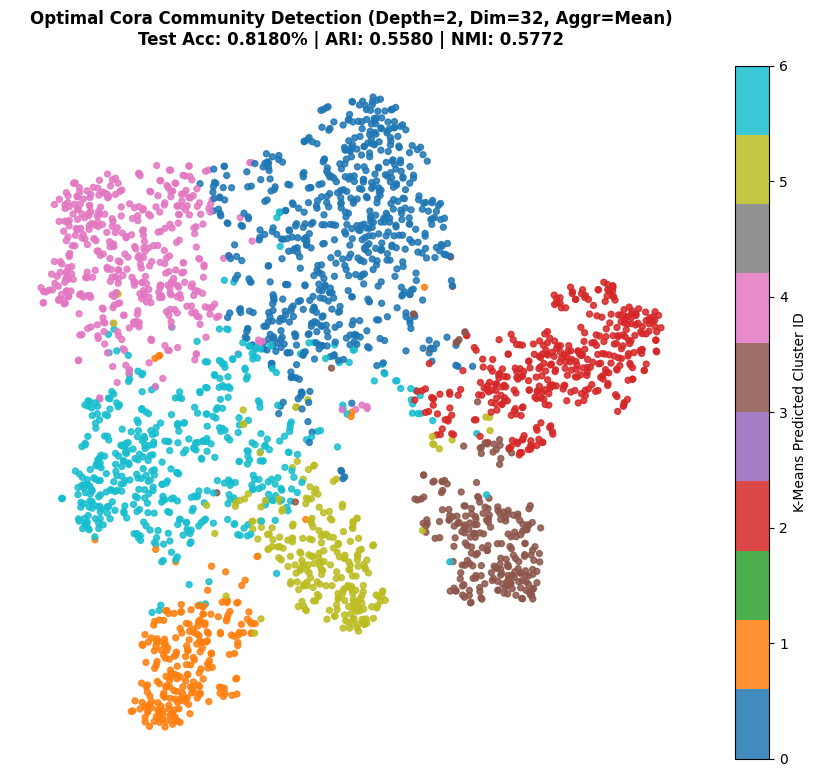

In [12]:
import sys
import os
#moving to community detection folder notebook folder like moving top
root_path=os.path.abspath(os.path.join('..'))
#now searching for src folder
src_path=os.path.join(root_path,'src')
#adding src path to pythons memory
if src_path not in sys.path:
    sys.path.append(src_path)
from Experiment_GCN_09 import OptimalAggregationGCN
from sklearn.manifold import TSNE
#intializing the optimized model

optimal_model = OptimalAggregationGCN(
    num_features=dataset.num_features, 
    num_classes=dataset.num_classes
).to(device)

optimizer = torch.optim.Adam(optimal_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()

#training the model and computing the accuracy

print("Training the ultimate model configuration...")
for epoch in range(1, 201):
    optimal_model.train()
    optimizer.zero_grad()
    out = optimal_model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

optimal_model.eval()
with torch.no_grad():
    out = optimal_model(data)
    pred = out.argmax(dim=1)
    correct = pred == data.y
    test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())
print(f"Optimal Model Test Accuracy: {test_acc * 100:.2f}%")

#extracting the node embeddings and running k means algorithm
with torch.no_grad():
    optimal_embeddings = optimal_model.conv1(data.x, data.edge_index)
    optimal_embeddings = F.relu(optimal_embeddings).cpu().numpy()

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(optimal_embeddings)
true_labels = data.y.cpu().numpy()
ari_score = adjusted_rand_score(true_labels, cluster_assignments)
nmi_score = normalized_mutual_info_score(true_labels, cluster_assignments)

#using t-SNE which is dimensionality reduction technique reduces 32 dim to 2d points 
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(optimal_embeddings)

plt.figure(figsize=(11, 9))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_assignments,
    cmap="tab10",
    s=18,
    alpha=0.85,
)

plt.colorbar(scatter, label="K-Means Predicted Cluster ID")
plt.title(
    f"Optimal Cora Community Detection (Depth=2, Dim=32, Aggr=Mean)\n"
    f"Test Acc: {test_acc :.4f}% | ARI: {ari_score:.4f} | NMI: {nmi_score:.4f}",
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.axis("off")  # Hides borders and axis lines for a clean presentation look
plt.show()


In [13]:
# Print the exact counts by summing up the True values in each binary mask
print("--- Exact Node Counts Per Split ---")
print(f"Total Nodes in Graph: {data.num_nodes}")
print(f"Training Nodes:       {int(data.train_mask.sum())}")
print(f"Validation Nodes:     {int(data.val_mask.sum())}")
print(f"Testing Nodes:        {int(data.test_mask.sum())}")

# Calculate unallocated nodes
unallocated = data.num_nodes - (int(data.train_mask.sum()) + int(data.val_mask.sum()) + int(data.test_mask.sum()))
print(f"Unallocated Nodes:    {unallocated}")

--- Exact Node Counts Per Split ---
Total Nodes in Graph: 2708
Training Nodes:       140
Validation Nodes:     500
Testing Nodes:        1000
Unallocated Nodes:    1068


we will not do this explict split this is done by dataset creator and we get that by planetoid library so that our results can directly compared with published research papers.


In [14]:
#now i got a doubt how does the model getting the test accuracy
#then in transductive learning the model knows the test nodes like their connections and features as we give entire graph as input to model
#but i want to check whether my model can completely predict the class or cluster a new paper that comes to the network ??
#for that we use inductive learning breaking the graph completely into train and test split and only train nodes for model training and complete graph for evaluation 
#preparing the data for training
from torch_geometric.utils import subgraph
import copy
#collecting the nodes which does not belong to test data 
train_nodes_mask = ~data.test_mask
#converts the boolean array to indices 
train_node_indices = train_nodes_mask.nonzero(as_tuple=False).view(-1)

# Slice the edge_index to completely remove any edges connected to test nodes
# relabel_nodes=True rewrites the node IDs so the training graph is completely self-contained
train_edge_index, _ = subgraph(train_nodes_mask, data.edge_index, relabel_nodes=True, num_nodes=data.num_nodes)

# Create a brand new, isolated training graph object
train_data = copy.copy(data)
train_data.x = data.x[train_nodes_mask]
train_data.y = data.y[train_nodes_mask]
train_data.edge_index = train_edge_index
train_data.train_mask = data.train_mask[train_nodes_mask]



In [15]:
#trying our optimized model on this inductive split
import sys
import os
#moving to community detection folder notebook folder like moving top
root_path=os.path.abspath(os.path.join('..'))
#now searching for src folder
src_path=os.path.join(root_path,'src')
#adding src path to pythons memory
if src_path not in sys.path:
    sys.path.append(src_path)
from Experiment_GCN_09 import InductiveGCN
from sklearn.manifold import TSNE

inductive_model=InductiveGCN(num_features=dataset.num_features,num_classes=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(inductive_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()

#training only on isolated graph of training
for epoch in range(1, 201):
    inductive_model.train()
    optimizer.zero_grad()
    # Notice we pass train_data features and train_data edge links only!
    out = inductive_model(train_data.x, train_data.edge_index)
    loss = criterion(out[train_data.train_mask], train_data.y[train_data.train_mask])
    loss.backward()
    optimizer.step()

#evaluating the test accuracy on unseen nodes
inductive_model.eval()
with torch.no_grad():
    # We pass the FULL data matrix now (introducing the unseen nodes and their links)
    out_full = inductive_model(data.x, data.edge_index)
    pred = out_full.argmax(dim=1)
    correct = pred == data.y
    inductive_test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())

print(f"\nInductive Evaluation Final Test Accuracy: {inductive_test_acc: .4f}%")


Inductive Evaluation Final Test Accuracy:  0.7770%


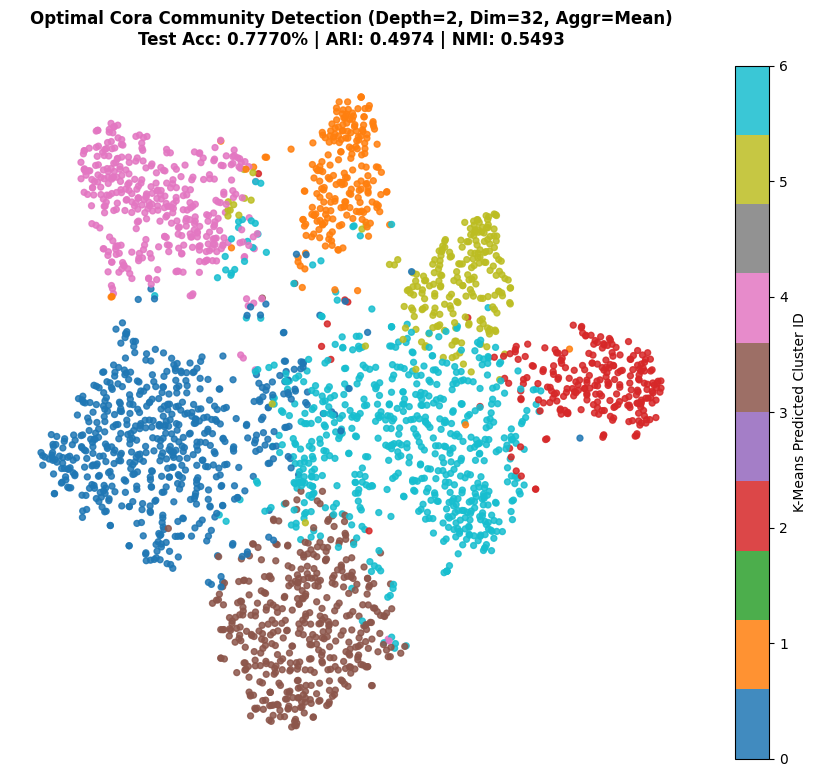

In [16]:
with torch.no_grad():
    optimal_embeddings = inductive_model.conv1(data.x, data.edge_index)
    optimal_embeddings = F.relu(optimal_embeddings).cpu().numpy()

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(optimal_embeddings)
true_labels = data.y.cpu().numpy()
ari_score = adjusted_rand_score(true_labels, cluster_assignments)
nmi_score = normalized_mutual_info_score(true_labels, cluster_assignments)

#using t-SNE which is dimensionality reduction technique reduces 32 dim to 2d points 
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(optimal_embeddings)

plt.figure(figsize=(11, 9))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_assignments,
    cmap="tab10",
    s=18,
    alpha=0.85,
)

plt.colorbar(scatter, label="K-Means Predicted Cluster ID")
plt.title(
    f"Optimal Cora Community Detection (Depth=2, Dim=32, Aggr=Mean)\n"
    f"Test Acc: {inductive_test_acc :.4f}% | ARI: {ari_score:.4f} | NMI: {nmi_score:.4f}",
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.axis("off")  # Hides borders and axis lines for a clean presentation look
plt.show()

now i got another idea like without using any graph structure y cany we just use node embeddings and try to do node classification and community detection 
then try to remove some of the edges and check how much our GCN architechture in actaully noice resilient

--> Evaluating GCN with 0% edges removed...
--> Evaluating GCN with 20% edges removed...
--> Evaluating GCN with 40% edges removed...
--> Evaluating GCN with 60% edges removed...


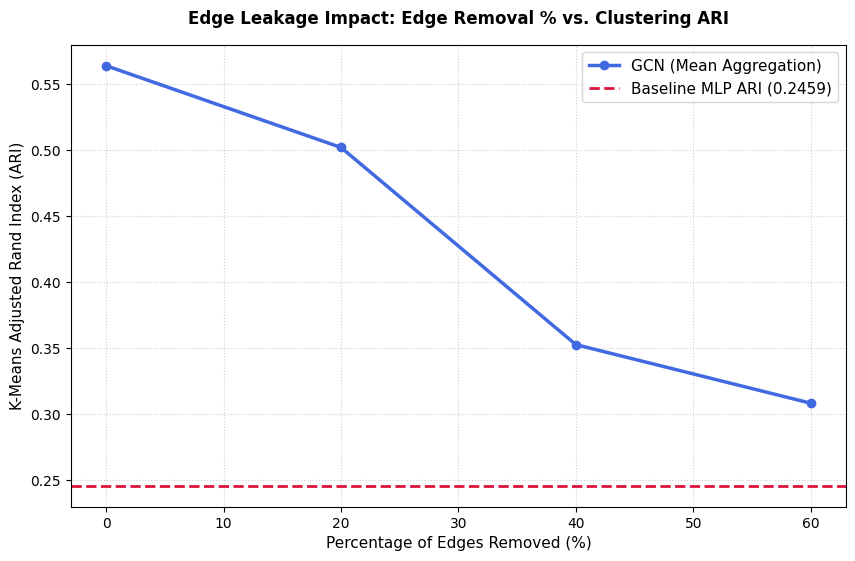


Edge Removal Summary Metrics:
Edges Removed (%) GCN Test Accuracy GCN Clustering ARI
               0%            79.10%             0.5640
              20%            78.20%             0.5021
              40%            72.50%             0.3528
              60%            66.20%             0.3084
MLP Baseline (No Graph Topology) - Test Acc: 57.50% | ARI: 0.2459


In [18]:
#first trying standard MLP without using any graph structure and next trying different kinds of dropouts
import sys
import os
#moving to community detection folder notebook folder like moving top
root_path=os.path.abspath(os.path.join('..'))
#now searching for src folder
src_path=os.path.join(root_path,'src')
#adding src path to pythons memory
if src_path not in sys.path:
    sys.path.append(src_path)
from Experiment_GCN_09 import InductiveGCN,BaselineMLP
from sklearn.manifold import TSNE
gcn_ari_scores=[]
gcn_accuracies=[]
#trying different dropout rates here 0 means all edges are present and 1.0 like increasing means edges are completely gone
dropout_rates=[0.0,0.2,0.4,0.6]

#baseline models
mlp_model = BaselineMLP(num_features=dataset.num_features, num_classes=dataset.num_classes).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()

for epoch in range(1, 201):
    mlp_model.train()
    mlp_optimizer.zero_grad()
    out = mlp_model(data.x) # Only passing node text features
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    mlp_optimizer.step()

#evaluating the model
mlp_model.eval()
with torch.no_grad():
    mlp_out = mlp_model(data.x)
    mlp_pred = mlp_out.argmax(dim=1)
    mlp_acc = int((mlp_pred == data.y)[data.test_mask].sum()) / int(data.test_mask.sum())
    
    # Extract 32D layer representation for clustering baseline
    mlp_embeddings = F.relu(mlp_model.fc1(data.x)).cpu().numpy()
    mlp_clusters = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(mlp_embeddings)
    mlp_ari = adjusted_rand_score(data.y.cpu().numpy(), mlp_clusters)


#trying the edge linkage
num_edges=data.edge_index.size(1)
for rate in dropout_rates:
    print(f"--> Evaluating GCN with {rate*100:.0f}% edges removed...")
    # Randomly choose which edge index vectors to keep based on the current rate
    keep_fraction = 1.0 - rate
    num_keep = int(keep_fraction * num_edges)

    #generating a random set of indices to keep edges     
    perm = torch.randperm(num_edges, device=device)
    keep_indices = perm[:num_keep]
    corrupted_edge_index = data.edge_index[:, keep_indices]

#uisng our optimized model on this one 
    model = InductiveGCN(num_features=dataset.num_features, num_classes=dataset.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    for epoch in range(1, 201):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, corrupted_edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        out = model(data.x, corrupted_edge_index)
        pred = out.argmax(dim=1)
        test_acc = int((pred == data.y)[data.test_mask].sum()) / int(data.test_mask.sum())
    #extracting the embeddings and run k means clustering    
        embeddings = model.conv1(data.x, corrupted_edge_index)
        embeddings = F.relu(embeddings).cpu().numpy()
        
    clusters = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(embeddings)
    ari = adjusted_rand_score(data.y.cpu().numpy(), clusters)
    
    # Save statistics
    gcn_ari_scores.append(ari)
    gcn_accuracies.append(test_acc)
#plotting the graphs
plt.figure(figsize=(10, 6))
removal_percentages = [rate * 100 for rate in dropout_rates]

# Plot GCN curve
plt.plot(removal_percentages, gcn_ari_scores, marker='o', linewidth=2.5, color='royalblue', label='GCN (Mean Aggregation)')
# Plot static MLP baseline line
plt.axhline(y=mlp_ari, color='crimson', linestyle='--', linewidth=2, label=f'Baseline MLP ARI ({mlp_ari:.4f})')

plt.title('Edge Leakage Impact: Edge Removal % vs. Clustering ARI', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Percentage of Edges Removed (%)', fontsize=11)
plt.ylabel('K-Means Adjusted Rand Index (ARI)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

# Show a quick summary dataframe of both metrics
df_leakage = pd.DataFrame({
    "Edges Removed (%)": [f"{p:.0f}%" for p in removal_percentages],
    "GCN Test Accuracy": [f"{acc*100:.2f}%" for acc in gcn_accuracies],
    "GCN Clustering ARI": [f"{ari:.4f}" for ari in gcn_ari_scores]
})
print("\nEdge Removal Summary Metrics:")
print(df_leakage.to_string(index=False))
print(f"MLP Baseline (No Graph Topology) - Test Acc: {mlp_acc*100:.2f}% | ARI: {mlp_ari:.4f}")




as we can see the results that the baseline MLP with only nodes features without any graph structure not given better result with accuracy around 58 and ARI around 0.24 that is why graph structure is important and if we remove the edges gradually the accuracy keeps on decreasing which also suggests that graph structure is very important

In [19]:
#till now we used 32d embeddings from layer1 inorder to do community detection now we are going to try with 7d output vector and check which perfrom better 
true_labels=data.y.cpu().numpy()
layer_results = {
    "Embedding Layer Used": ["Layer 1 (32D Hidden)", "Final Layer (7D Output)"],
    "K-Means ARI": [],
    "K-Means NMI": []
}
#clustering with normal layer1 32d embeddings
with torch.no_grad():
    hidden_32d = optimal_model.conv1(data.x, data.edge_index)
    hidden_32d = F.relu(hidden_32d).cpu().numpy()

clusters_32d = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(hidden_32d)
ari_32d = adjusted_rand_score(true_labels, clusters_32d)
nmi_32d = normalized_mutual_info_score(true_labels, clusters_32d)

layer_results["K-Means ARI"].append(f"{ari_32d:.4f}")
layer_results["K-Means NMI"].append(f"{nmi_32d:.4f}")

In [20]:
#clustering with final layer 7d output vector 
with torch.no_grad():
    output_7d = optimal_model(data).cpu().numpy()

clusters_7d = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(output_7d)
ari_7d = adjusted_rand_score(true_labels, clusters_7d)
nmi_7d = normalized_mutual_info_score(true_labels, clusters_7d)

layer_results["K-Means ARI"].append(f"{ari_7d:.4f}")
layer_results["K-Means NMI"].append(f"{nmi_7d:.4f}")
print("Layer Embedding Experiment Results:")
df_layers = pd.DataFrame(layer_results)
print(df_layers.to_string(index=False))

Layer Embedding Experiment Results:
   Embedding Layer Used K-Means ARI K-Means NMI
   Layer 1 (32D Hidden)      0.5580      0.5772
Final Layer (7D Output)      0.2623      0.4860


by seeing the result we can say that the performance was way better while we are using 13d hidden dimensional vectors because they preserve continous,distributed representations of feature geometry which makes them ideal fro unsupervised learning like community detection and when it comes to final layer embeddings because of their dimensionality reduction for classification purpose making them less suitable for this taks

graph homopholy is one of the important concept like it is commonly termed as love of sameness where people with same features/emddings/categories are connected to each other. now this cora dataset is 0.81% homophile so if we randomly pick a citation from a paper then there is 81% chance that they belong to same category.
The main use of this GCN is to use this high homophile and make the node embeddings.
suppose if a neural networks paper is connected to 5 crptographic papers then if we aggregate the info from neighbors then it will alos become similar to those which is not so the netwrok is not strong homophile so i would like to check my GCN on those type non homophile graph structures whether it will work well or not.

we will try to test this homophile on misclassified nodes and is the homophile is low then we can say that the GCN is very much dependent on nodes local structure but if the homophile is high we can say that the nodes embeddings caused the trouble in classification.

In [22]:
#first making the predictions using optimal model
inductive_model.eval()
with torch.no_grad():
    out = inductive_model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
#now use then CPU numpy for easy indexing
preds_np = pred.cpu().numpy()
labels_np = data.y.cpu().numpy()
test_mask_np = data.test_mask.cpu().numpy()

#identifying the misclassified node indices
#finding nodes where predicted label is not equal to true label and belong to test set
misclassified_mask = (preds_np != labels_np) & test_mask_np
misclassified_node_ids = np.where(misclassified_mask)[0]

print(f"Total misclassified test nodes found: {len(misclassified_node_ids)}")
#here we try to look at the each misclassified neighbors and check
neighbor_homophily_scores = []
edge_index_np = data.edge_index.cpu().numpy()
for node in misclassified_node_ids:
    true_label = labels_np[node]
    #here we are getting the true label of misclassified node 
    # Find all incoming and outgoing neighbors for this specific node
    # Since Cora is directed but treated as undirected, we check both rows of edge_index
    neighbors_from_src = edge_index_np[1, edge_index_np[0, :] == node]
    neighbors_from_dst = edge_index_np[0, edge_index_np[1, :] == node]
    neighbors = np.unique(np.concatenate([neighbors_from_src, neighbors_from_dst]))
    
    if len(neighbors) == 0:
        continue  # Skip isolated nodes if any exist
        
    # Count how many neighbors share the target node's true label
    matching_neighbors = np.sum(labels_np[neighbors] == true_label)
    
    # Calculate the fraction (local homophily ratio)
    homophily_fraction = matching_neighbors / len(neighbors)
    neighbor_homophily_scores.append(homophily_fraction)

Total misclassified test nodes found: 223


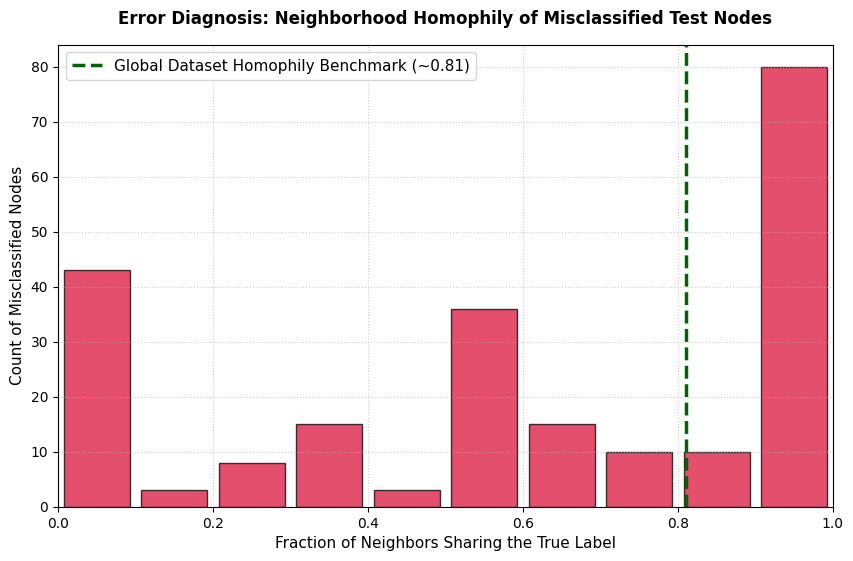

Average local homophily for misclassified nodes: 0.5962


In [23]:
#now we will try to vizualize the homophily sistribution using histogram
plt.figure(figsize=(10, 6))

# Plotting a histogram of the homophily distribution
plt.hist(
    neighbor_homophily_scores, 
    bins=10, 
    range=(0, 1), 
    color='crimson', 
    edgecolor='black', 
    alpha=0.75, 
    rwidth=0.85
)

# Add a vertical line marking the global dataset homophily benchmark (~0.81)
plt.axvline(x=0.81, color='darkgreen', linestyle='--', linewidth=2.5, label='Global Dataset Homophily Benchmark (~0.81)')

# Plot labeling
plt.title('Error Diagnosis: Neighborhood Homophily of Misclassified Test Nodes', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Fraction of Neighbors Sharing the True Label', fontsize=11)
plt.ylabel('Count of Misclassified Nodes', fontsize=11)
plt.xlim(0, 1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

# Calculate and print the average
avg_homophily_error = np.mean(neighbor_homophily_scores)
print(f"Average local homophily for misclassified nodes: {avg_homophily_error:.4f}")

from the graph we can say that intially around 40 nodes were misclassifed due to 0% homophily means their neighbors are not their true label all belong to different labels and with the homophily 20% , 40% were less because even though their neighbors are not that much their embeddings are taking care of classification and at the right most even afer we are having 90 to 100% homophile there are many misclassified nodes this is because of incorrect embedding in the nodes vector in coas dataset and thorugh this we can say that out GCN good noise resilient as even though the graph structure is not good due to that there are less no nodes misclassified that y .

And that score of aroud 60% means if we take any misclassified node due to this GCN on cora dataset it will have an homophile of aroung 60% means 60% of its neighbors are belongs to its true label

so when a node as homophile structure of 0.8 which is general for all nodes the they get clssified correctly but sas it drops to 60 then only misclassification occurs